# **Практическая работа №1. Основные методы OpenCV. Часть №1**

---

# **Тема №1. Чтение, запись и отображение**

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import requests
from io import BytesIO



## **Задание 1:**  
Напишите процедуру, которая:

- Считывает цветное изображение в режиме `cv2.IMREAD_COLOR`.
- Преобразует его в оттенки серого с использованием `cv2.cvtColor()`.
- Сохраняет полученное черно-белое изображение на диск.
- Отображает оба изображения (оригинальное цветное и преобразованное черно-белое).




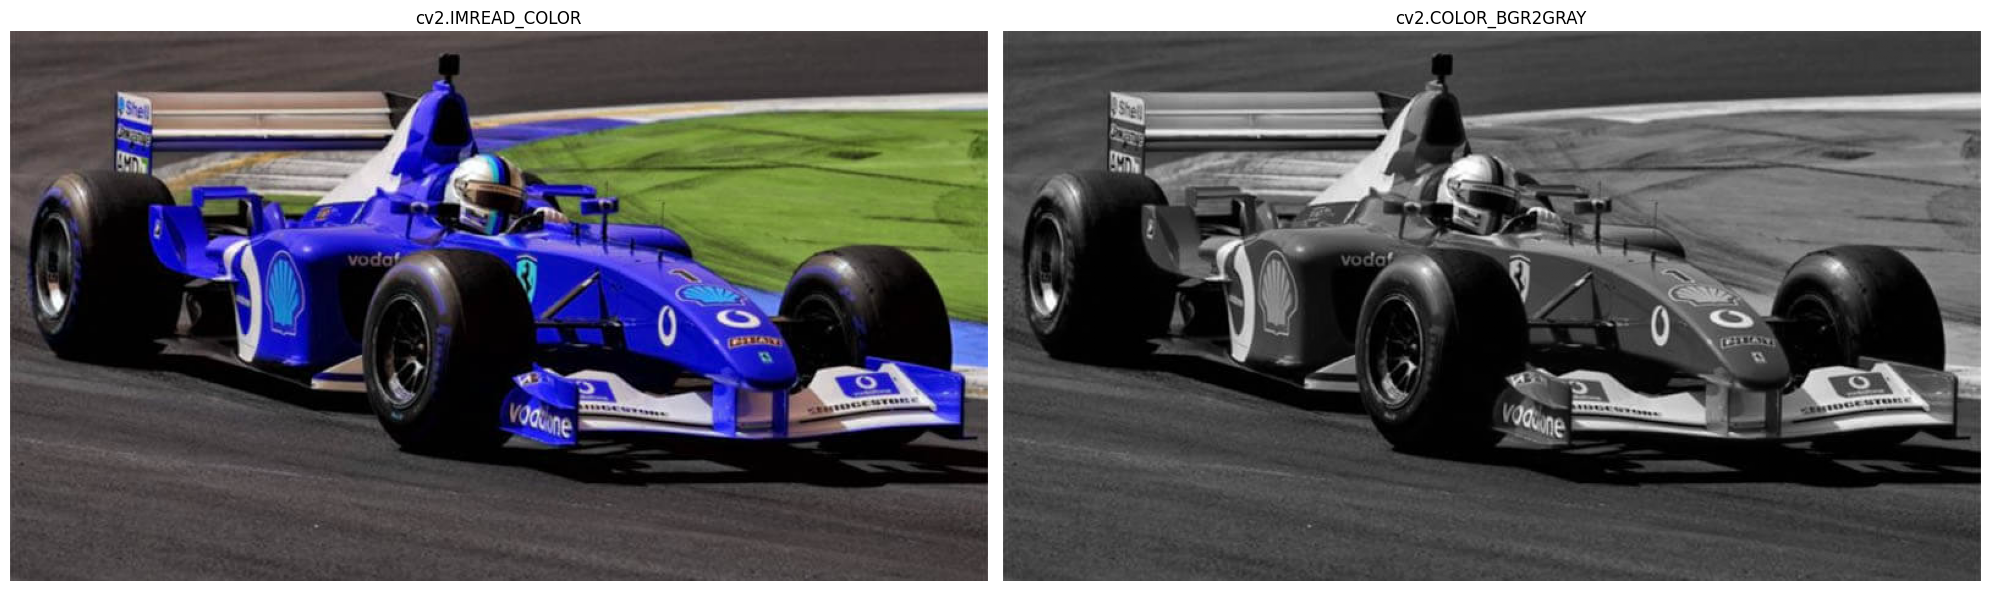

In [2]:
def task_1(url):
  resp = requests.get(url, stream=True).raw
  img = np.asarray(bytearray(resp.read()), dtype='uint8')
  img = cv2.imdecode(img, cv2.IMREAD_COLOR)
  dst = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
  cv2.imwrite('dst_task_1.jpg', dst)

  plt.figure(figsize=(20, 10))

  plt.subplot(1, 2, 1)
  plt.imshow(img)
  plt.title('cv2.IMREAD_COLOR')
  plt.axis('off')

  plt.subplot(1, 2, 2)
  plt.imshow(dst, cmap='gray')
  plt.title('cv2.COLOR_BGR2GRAY')
  plt.axis('off')

  plt.tight_layout()
  plt.show()


URL = r'https://queen-of-motorsport.com/wp-content/uploads/2026/09/vettel-schumacher-f1-monza-italiangp.jpg'
task_1(URL)

## **Задание 2:**  
Используя режим `cv2.IMREAD_UNCHANGED`, загрузите изображение с альфа-каналом (например, PNG с прозрачностью). Затем:

- Разделите изображение на каналы (B, G, R, A).
- Создайте новое изображение, где прозрачность (альфа-канал) инвертирована (т.е. прозрачные области становятся непрозрачными и наоборот).
- Сохраните и отобразите полученное изображение.

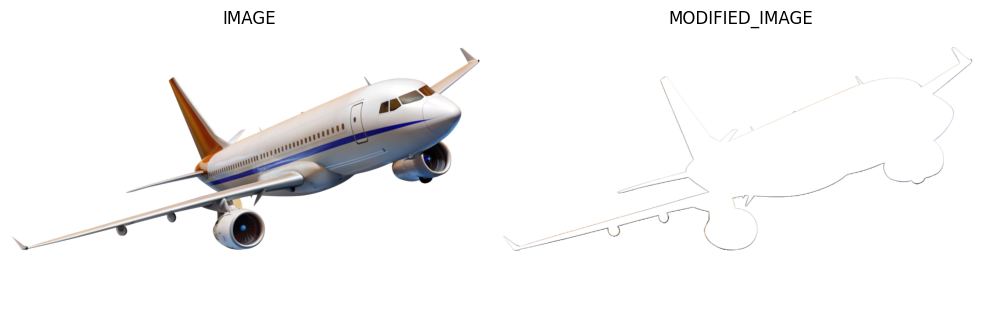

In [3]:
URL = r'https://i.pinimg.com/originals/d7/94/b5/d794b5f758cbfe8b75fc27cb14a763aa.png?nii=t'

resp = requests.get(URL, stream=True).raw
img = np.asarray(bytearray(resp.read()), dtype='uint8')
img = cv2.imdecode(img, cv2.IMREAD_UNCHANGED)

b, g, r, a = cv2.split(img)
inverted_a = cv2.bitwise_not(a)

new_image = cv2.merge([b, g, r, inverted_a])

plt.figure(figsize=(10, 8))

plt.subplot(1, 2, 1)
plt.imshow(img)
plt.title('IMAGE')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(new_image)
plt.title('MODIFIED_IMAGE')
plt.axis('off')

plt.tight_layout()
plt.show()


---

# **Тема №2. Работа с цветовыми палитрами**



## **Задание 3:**  
Напишите процедуру, которая:

- Считывает цветное изображение.
- Преобразует его из цветового пространства BGR в HSV с помощью `cv2.cvtColor()`.
- Увеличивает насыщенность (канал S) в 1.5 раза, не превышая максимального значения.
- Преобразует изображение обратно в цветовое пространство BGR.
- Отображает оригинальное и полученное изображения рядом для сравнения.

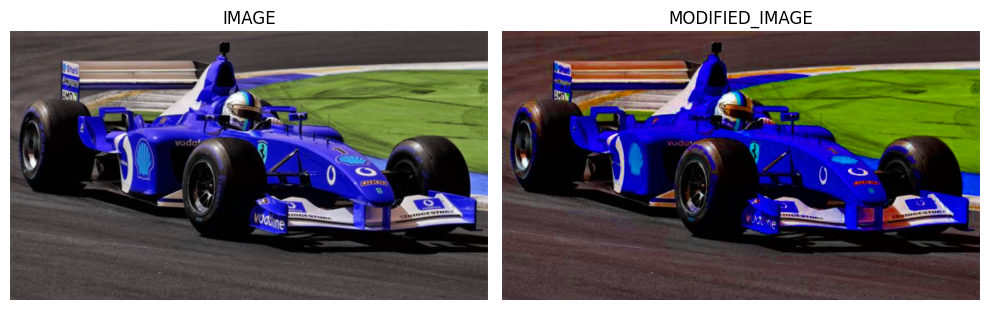

In [4]:
def task_3(url, scale=1.5):
  resp = requests.get(url, stream=True).raw
  bgr_img = np.asarray(bytearray(resp.read()), dtype='uint8')
  bgr_img = cv2.imdecode(bgr_img, cv2.IMREAD_COLOR)
  hsv_img = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2HSV)

  h, s, v = cv2.split(hsv_img)
  s = cv2.multiply(s, scale)
  s = np.clip(s, 0, 255).astype(np.uint8)
  hsv_img = cv2.merge([h, s, v])
  result = cv2.cvtColor(hsv_img, cv2.COLOR_HSV2BGR)

  plt.figure(figsize=(10, 8))

  plt.subplot(1, 2, 1)
  plt.imshow(bgr_img)
  plt.title('IMAGE')
  plt.axis('off')

  plt.subplot(1, 2, 2)
  plt.imshow(result)
  plt.title('MODIFIED_IMAGE')
  plt.axis('off')

  plt.tight_layout()
  plt.show()



URL = r'https://queen-of-motorsport.com/wp-content/uploads/2026/09/vettel-schumacher-f1-monza-italiangp.jpg'
task_3(URL, scale=3)

## **Задание 4:**  
Напишите процедуру, которая:

- Считывает изображение и Преобразует его в цветовое пространство YCrCb.
- Применяет размытие к компоненте яркости Y (при помощи фильтра, см. материал предыдущих занятий).
- Снова Преобразует изображение в цветовое пространство BGR.
- Отображает исходное и размытое изображения.

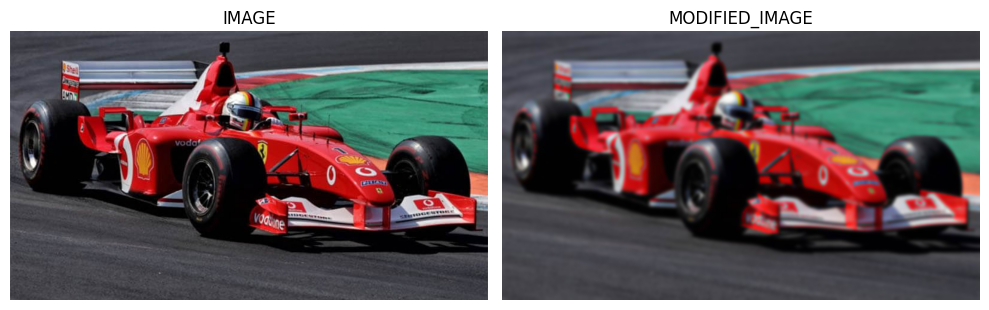

In [5]:
def task_4(url):
  resp = requests.get(url, stream=True).raw
  bgr_img = np.asarray(bytearray(resp.read()), dtype='uint8')
  bgr_img = cv2.imdecode(bgr_img, cv2.IMREAD_COLOR)
  rgb_img = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2RGB)
  YCrCb_img = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2YCrCb)

  Y, Cr, Cb = cv2.split(YCrCb_img)
  Y = cv2.GaussianBlur(Y, (15, 15), 0)
  YCrCb_img = cv2.merge([Y, Cr, Cb])
  result = cv2.cvtColor(YCrCb_img, cv2.COLOR_YCrCb2RGB)

  plt.figure(figsize=(10, 8))

  plt.subplot(1, 2, 1)
  plt.imshow(rgb_img)
  plt.title('IMAGE')
  plt.axis('off')

  plt.subplot(1, 2, 2)
  plt.imshow(result)
  plt.title('MODIFIED_IMAGE')
  plt.axis('off')

  plt.tight_layout()
  plt.show()



URL = r'https://queen-of-motorsport.com/wp-content/uploads/2026/09/vettel-schumacher-f1-monza-italiangp.jpg'
task_4(URL)

---

# **Тема №3. Слияние и усиление**

## **Задание 5:**  
Создайте процедуру, которая:

- Считывает два изображения одинакового размера (можно подкорректировать с помощью метода `.resize()`).
- Выполняет побитовое ИЛИ (OR) над соответствующими пикселями двух изображений.
- Сохраняет и отображает результат операции.

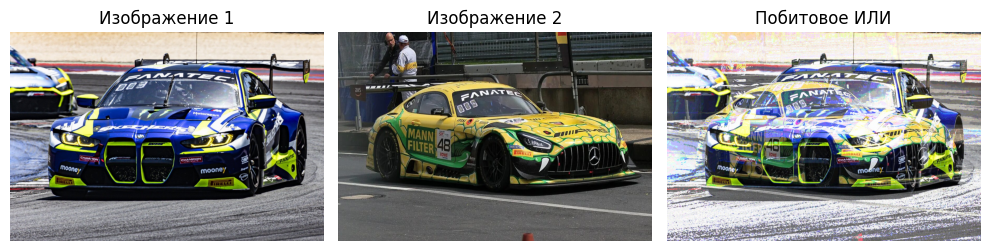

In [31]:
def task_5(url1, url2):
  resp1 = requests.get(url1, stream=True).raw
  bgr_img1 = np.asarray(bytearray(resp1.read()), dtype='uint8')
  bgr_img1 = cv2.imdecode(bgr_img1, cv2.IMREAD_COLOR)
  h, w = bgr_img1.shape[:2]

  resp2 = requests.get(url2, stream=True).raw
  bgr_img2 = np.asarray(bytearray(resp2.read()), dtype='uint8')
  bgr_img2 = cv2.imdecode(bgr_img2, cv2.IMREAD_COLOR)
  bgr_img2 = cv2.resize(bgr_img2, (w, h))

  result = cv2.bitwise_or(bgr_img1, bgr_img2)

  plt.figure(figsize=(10, 8))

  plt.subplot(1, 3, 1)
  plt.imshow(cv2.cvtColor(bgr_img1, cv2.COLOR_BGR2RGB))
  plt.title('Изображение 1')
  plt.axis('off')

  plt.subplot(1, 3, 2)
  plt.imshow(cv2.cvtColor(bgr_img2, cv2.COLOR_BGR2RGB))
  plt.title('Изображение 2')
  plt.axis('off')

  plt.subplot(1, 3, 3)
  plt.imshow(cv2.cvtColor(result, cv2.COLOR_BGR2RGB))
  plt.title('Побитовое ИЛИ')
  plt.axis('off')

  plt.tight_layout()
  plt.show()

URL1 = 'https://motogonki.ru/images/news/newsimage_202307191327202.peg'
URL2 = 'https://avatars.mds.yandex.net/i?id=92660cfa4a3d48f7457ee892945f6131_l-3891756-images-thumbs&n=13'
task_5(URL1, URL2)

## **Задание 6:**  
Реализуйте следующий алгоритм:

- Считайте цветное изображение и разделите его на три канала с использованием `.split()`.
- Примените к каждому каналу разный коэффициент гамма-коррекции (например, для R – 0.5, G – 1.0, B – 1.5).
- Объедините каналы обратно с помощью `.merge()`.
- Отобразите исходное и обработанное изображения.


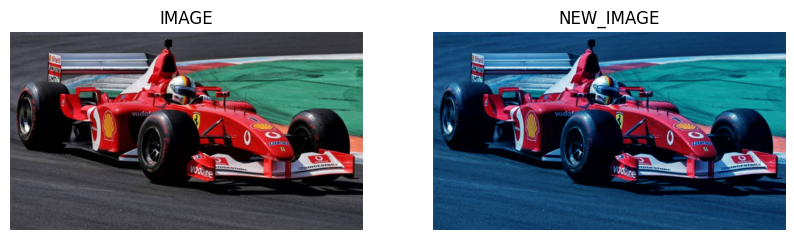

In [15]:
def adjusted_image(image, gamma):
  inv_gamma = 1 / gamma
  table = np.array([((i / 255.0) ** inv_gamma) * 255 for i in np.arange(0, 256)]).astype(np.uint8)
  return cv2.LUT(image, table)

URL = 'https://queen-of-motorsport.com/wp-content/uploads/2026/09/vettel-schumacher-f1-monza-italiangp.jpg'

resp = requests.get(URL, stream=True).raw
bgr_img = np.asarray(bytearray(resp.read()), dtype='uint8')
bgr_img = cv2.imdecode(bgr_img, cv2.IMREAD_COLOR)

B, G, R = cv2.split(bgr_img)

B = adjusted_image(B, 1.5)
G = adjusted_image(G, 1.0)
R = adjusted_image(R, 0.5)

result = cv2.merge([B, G, R])

rgb_img = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2RGB)
result = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 8))

plt.subplot(1, 2, 1)
plt.imshow(rgb_img)
plt.title('IMAGE')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(result)
plt.title('NEW_IMAGE')
plt.axis('off')

plt.show()

---

# **Тема №4. Работа с гистограммами в OpenCV**

## **Задание 7:**  
Напишите процедуру для улучшения контрастности изображения:

- Считывает изображение в оттенках серого.
- Строит его гистограмму с использованием `cv.calcHist()`.
- Применяет эквализацию гистограммы методом `cv2.equalizeHist()`.
- Отображает на одном графике исходное и эквализованное изображения вместе с их гистограммами.

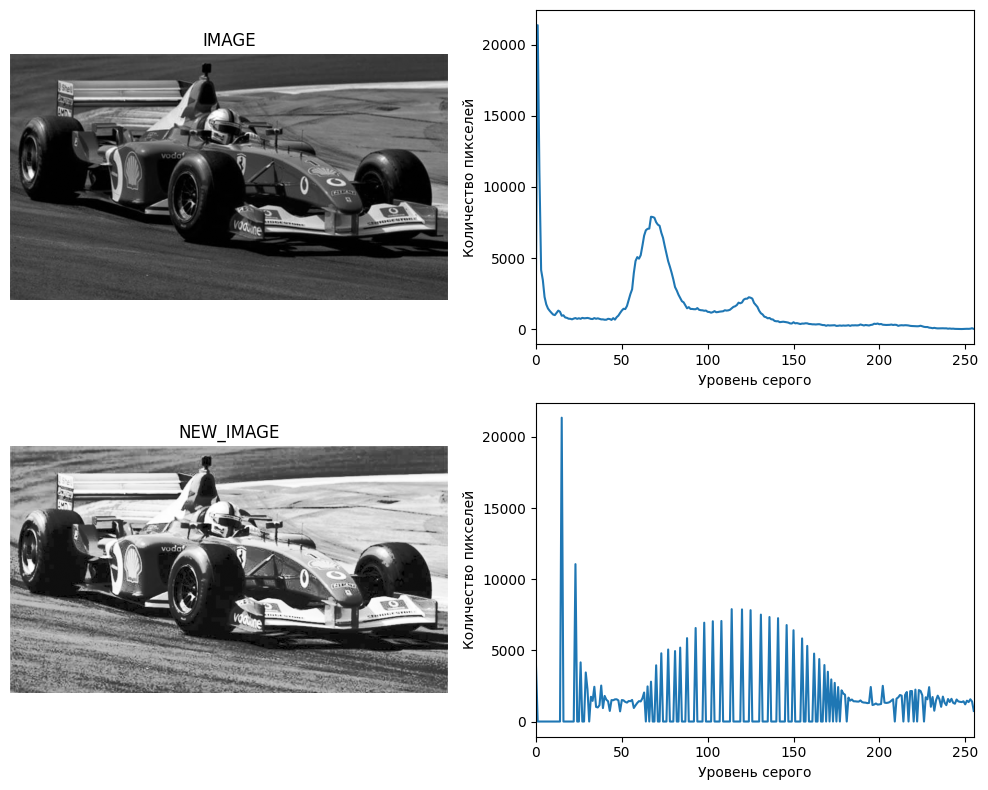

In [22]:
def task_7(url):
  resp = requests.get(URL, stream=True).raw
  bgr_img = np.asarray(bytearray(resp.read()), dtype='uint8')
  bgr_img = cv2.imdecode(bgr_img, cv2.IMREAD_COLOR)
  gray_img = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2GRAY)

  hist = cv2.calcHist([gray_img], [0], None, [256], [0, 256])

  equa_img = cv2.equalizeHist(gray_img)

  equa_hist = cv2.calcHist([equa_img], [0], None, [256], [0, 256])

  plt.figure(figsize=(10, 8))

  plt.subplot(2, 2, 1)
  plt.imshow(gray_img, cmap='gray')
  plt.title('IMAGE')
  plt.axis('off')

  plt.subplot(2, 2, 2)
  plt.plot(hist)
  plt.xlim([0, 255])
  plt.xlabel('Уровень серого')
  plt.ylabel('Количество пикселей')

  plt.subplot(2, 2, 3)
  plt.imshow(equa_img, cmap='gray')
  plt.title('NEW_IMAGE')
  plt.axis('off')

  plt.subplot(2, 2, 4)
  plt.plot(equa_hist)
  plt.xlim([0, 255])
  plt.xlabel('Уровень серого')
  plt.ylabel('Количество пикселей')

  plt.tight_layout()
  plt.show()

URL = 'https://queen-of-motorsport.com/wp-content/uploads/2026/09/vettel-schumacher-f1-monza-italiangp.jpg'
task_7(URL)

## **Задание 8:**  
Используйте метод CLAHE для улучшения деталей в затемненных областях цветного изображения:

- Преобразуйте изображение из BGR в LAB цветовое пространство.
- Разделите изображение на каналы и примените `cv2.createCLAHE()` к каналу яркости L.
- Объедините обработанный канал L с исходными каналами A и B.
- Преобразуйте изображение обратно в BGR.
- Отобразите исходное и обработанное изображения для сравнения вместе с их гистограммами.

In [24]:
def img2hist(temp_img, title, label=True):
    if temp_img.ndim == 3:
        values = cv2.cvtColor(temp_img, cv2.COLOR_BGR2YCrCb)[:, :, 0]
        channel_name = "Y"
    else:
        values = temp_img
        channel_name = "уровня серого"

    if label:
        print(f"Среднее значение {channel_name}: {values.mean():.2f}")
        print(f"Минимум: {values.min()}")
        print(f"Максимум: {values.max()}")

    plt.figure(figsize=(10, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(temp_img, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.hist(values.ravel(), bins=256, range=(0, 256))
    plt.xlim([0, 255])
    plt.xlabel("Интенсивность")
    plt.ylabel("Количество пикселей")

    plt.tight_layout()
    plt.show()

Среднее значение Y: 73.61
Минимум: 0
Максимум: 255


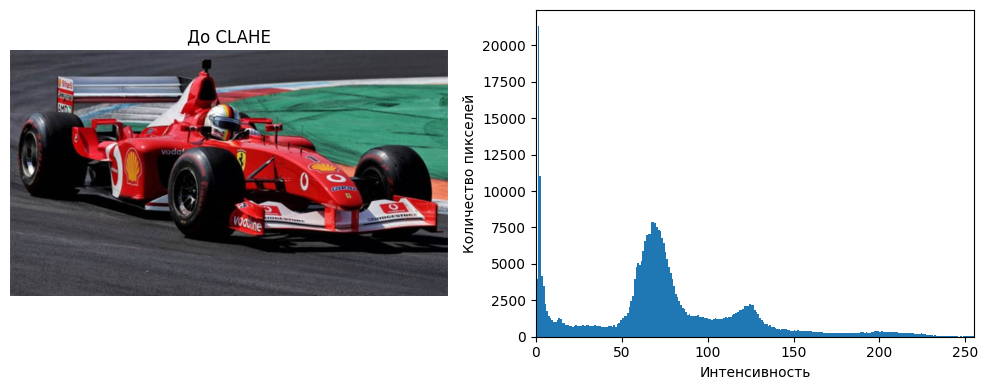

Среднее значение Y: 88.70
Минимум: 2
Максимум: 255


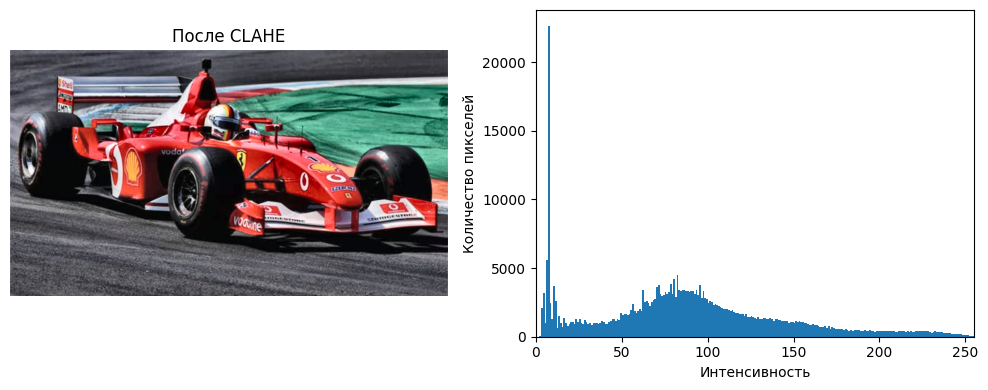

In [25]:
URL = 'https://queen-of-motorsport.com/wp-content/uploads/2026/09/vettel-schumacher-f1-monza-italiangp.jpg'

resp = requests.get(URL, stream=True).raw
bgr_img = np.asarray(bytearray(resp.read()), dtype='uint8')
bgr_img = cv2.imdecode(bgr_img, cv2.IMREAD_COLOR)
lab_img = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2LAB)

L, A, B = cv2.split(lab_img)

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
L = clahe.apply(L)

result = cv2.merge([L, A, B])
result = cv2.cvtColor(result, cv2.COLOR_LAB2BGR)

img2hist(bgr_img, title='До CLAHE')
img2hist(result, title='После CLAHE')

## **Затем:**  
Исследуйте влияние размера окна (tileGridSize) и порога по сравнению с гистограммой (clipLimit) в методе CLAHE на конечный результат. Попробуйте несколько различных значений и визуализируйте результаты.


Среднее значение Y: 73.61
Минимум: 0
Максимум: 255


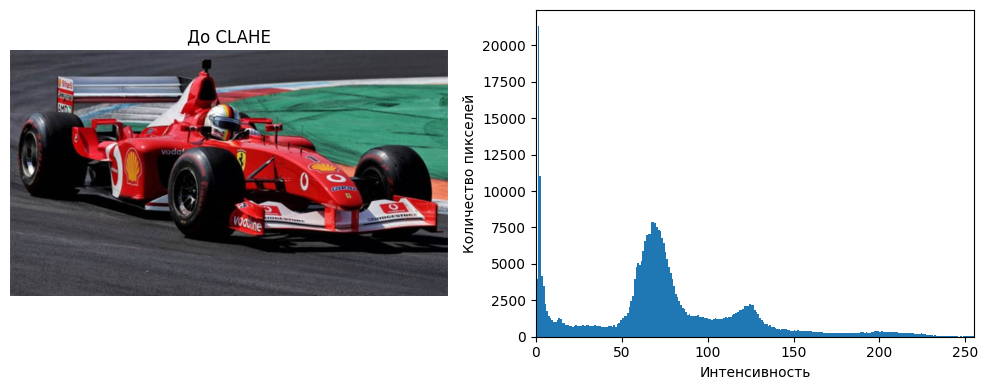

Среднее значение Y: 90.81
Минимум: 2
Максимум: 255


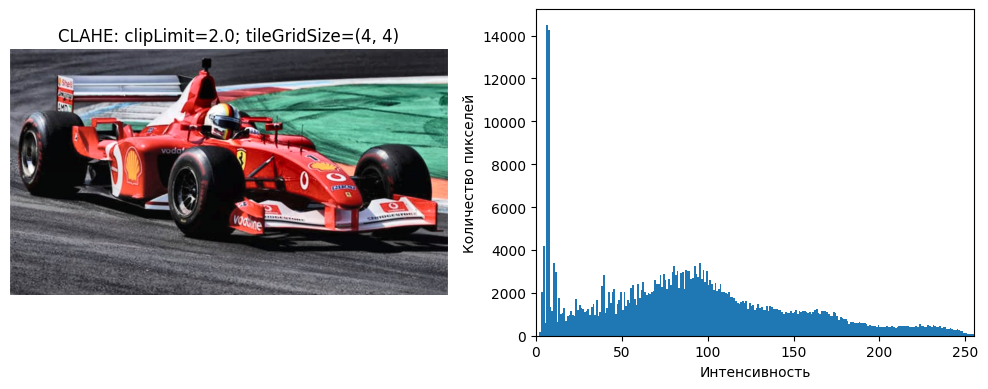

Среднее значение Y: 88.70
Минимум: 2
Максимум: 255


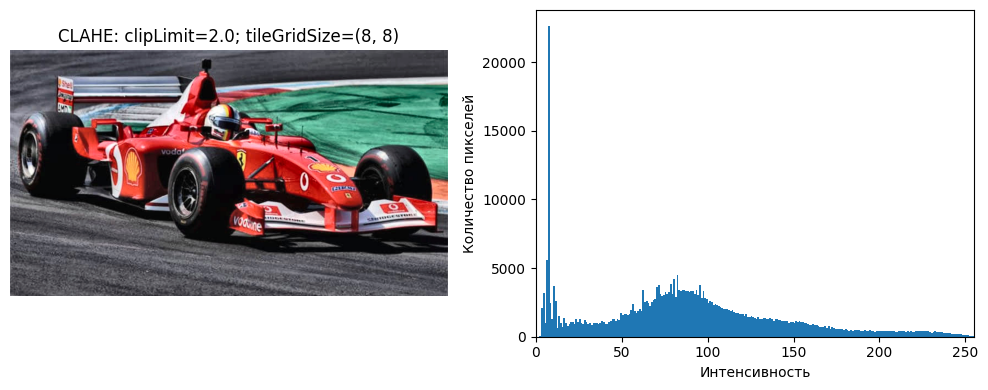

Среднее значение Y: 87.88
Минимум: 2
Максимум: 255


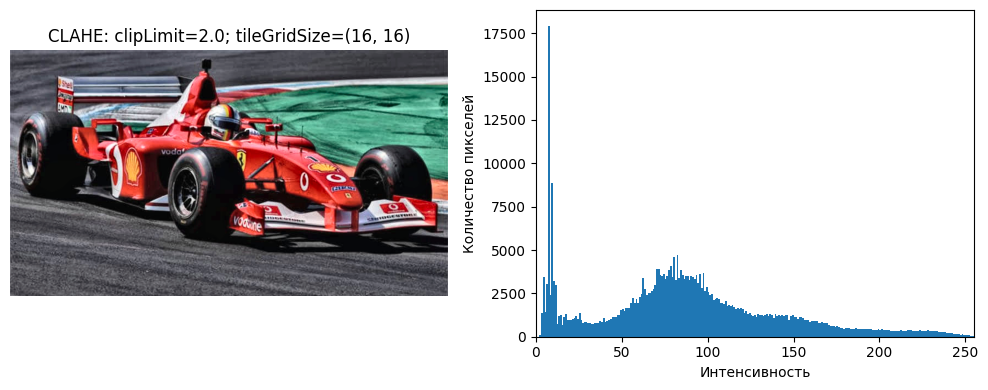

Среднее значение Y: 83.45
Минимум: 2
Максимум: 255


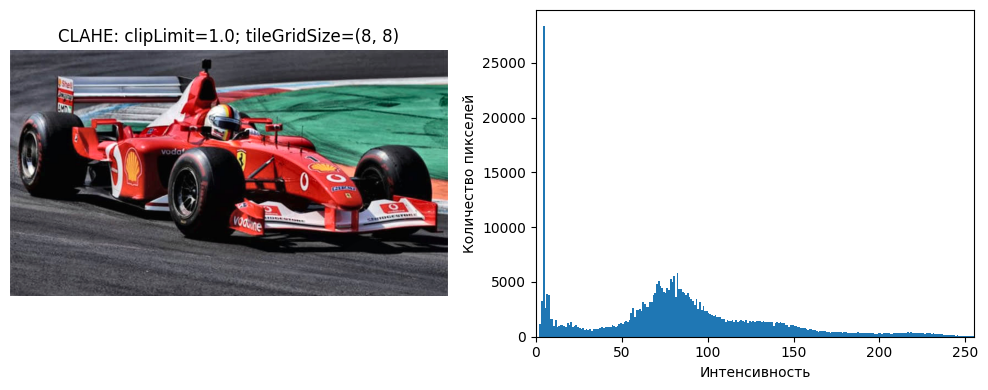

Среднее значение Y: 95.87
Минимум: 2
Максимум: 255


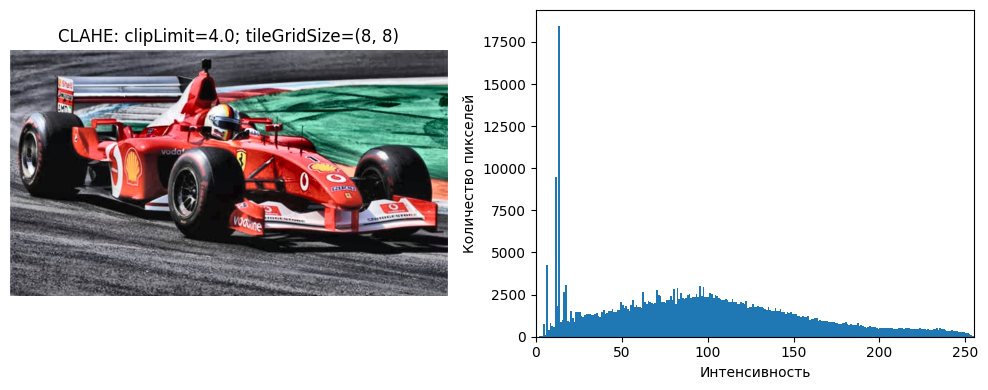

In [32]:
URL = 'https://queen-of-motorsport.com/wp-content/uploads/2026/09/vettel-schumacher-f1-monza-italiangp.jpg'

resp = requests.get(URL, stream=True).raw
bgr_img = np.asarray(bytearray(resp.read()), dtype='uint8')
bgr_img = cv2.imdecode(bgr_img, cv2.IMREAD_COLOR)
lab_img = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2LAB)

# clipLimit=2.0; tileGridSize=(4, 4)
L, A, B = cv2.split(lab_img)

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(4, 4))
L = clahe.apply(L)

result = cv2.merge([L, A, B])
result = cv2.cvtColor(result, cv2.COLOR_LAB2BGR)

img2hist(bgr_img, title='До CLAHE')
img2hist(result, title='CLAHE: clipLimit=2.0; tileGridSize=(4, 4)')

# clipLimit=2.0; tileGridSize=(8, 8)
L, A, B = cv2.split(lab_img)

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
L = clahe.apply(L)

result = cv2.merge([L, A, B])
result = cv2.cvtColor(result, cv2.COLOR_LAB2BGR)

img2hist(result, title='CLAHE: clipLimit=2.0; tileGridSize=(8, 8)')

# clipLimit=2.0; tileGridSize=(16, 16)
L, A, B = cv2.split(lab_img)

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(16, 16))
L = clahe.apply(L)

result = cv2.merge([L, A, B])
result = cv2.cvtColor(result, cv2.COLOR_LAB2BGR)

img2hist(result, title='CLAHE: clipLimit=2.0; tileGridSize=(16, 16)')

# clipLimit=1.0; tileGridSize=(8, 8)
L, A, B = cv2.split(lab_img)

clahe = cv2.createCLAHE(clipLimit=1.0, tileGridSize=(8, 8))
L = clahe.apply(L)

result = cv2.merge([L, A, B])
result = cv2.cvtColor(result, cv2.COLOR_LAB2BGR)

img2hist(result, title='CLAHE: clipLimit=1.0; tileGridSize=(8, 8)')

# clipLimit=4.0; tileGridSize=(8, 8)
L, A, B = cv2.split(lab_img)

clahe = cv2.createCLAHE(clipLimit=4.0, tileGridSize=(8, 8))
L = clahe.apply(L)

result = cv2.merge([L, A, B])
result = cv2.cvtColor(result, cv2.COLOR_LAB2BGR)

img2hist(result, title='CLAHE: clipLimit=4.0; tileGridSize=(8, 8)')

---

# **Комплексное задание №1. Улучшение качества отсканированного документа с использованием OpenCV**



## **Краткое описание задания:**

- Необходимо написать функцию для улучшения качества отсканированного документа с использованием методов обработки изображений, изученных ранее. Функция должна принимать на вход изображение отсканированного документа и возвращать его улучшенную версию, готовую для дальнейшего использования, например, для распознавания текста.

Датасет с отсканированными изображениями можно найти в сети Интернет.

---



## **Алгоритм действий:**

#### **Реализуйте функцию на языке Python с использованием библиотеки OpenCV, которая выполняет следующие этапы обработки:**

### **1. Чтение, запись и отображение изображений:**

- Функция должна принимать на вход изображение отсканированного документа (например, в формате JPEG или PNG)
- Проверьте наличие альфа-канала в изображении и, если он присутствует, загрузите изображение в режиме `cv2.IMREAD_UNCHANGED`, иначе используйте `cv2.IMREAD_COLOR`
- Отобразите исходное изображение для визуальной проверки

### **2. Работа с цветовыми палитрами:**

- Преобразуйте изображение в оттенки серого, используя `cv2.cvtColor()` с параметром `cv2.COLOR_BGR2GRAY`.
- Отобразите полученное изображение в оттенках серого.

### **3. Слияние и усиление:**

- Примените медианный фильтр (`cv2.medianBlur()`) для удаления шумов с изображения. Выберите подходящий размер ядра (например, 3 или 5). Отобразите результат.
- Используйте фильтр сглаживания с применением прямой свертки (`cv2.filter2D()`) с заданным ядром для повышения четкости. Например, можно использовать фильтр "Unsharp Masking":
  - Создайте ядро для повышения резкости. Пример ядра:
    ```python
    kernel = np.array([[-1, -1, -1],
                       [-1,  9, -1],
                       [-1, -1, -1]])
    ```
  - Примените фильтр к изображению и отобразите результат.

### **4. Работа с гистограммами:**

- Примените метод CLAHE (Contrast Limited Adaptive Histogram Equalization) для улучшения контрастности изображения:
  - Создайте объект CLAHE с параметрами `clipLimit=2.0` и `tileGridSize=(8,8)`.
  - Примените CLAHE к изображению.
  - отобразите результат.
- Постройте гистограммы яркости исходного и обработанного изображений для сравнения.

---

### **Требования к функции:**

- Функция должна называться: `improve_scan(image)`, где `image` — входное изображение в виде массива NumPy.
- Функция должна возвращать улучшенное изображение в виде массива NumPy.
- В ходе работы функция должна **опционально** отображать промежуточные результаты для наглядности (в условиях Colab использовать соответствующие методы вывода изображений). Для этого следует ввести отдельный параметр (например: `visible=True`) и реализовать с ним соответствующую логику.

---

### **Дополнительные требования:**

- **Обработка ошибок:**
  - Убедитесь, что функция корректно обрабатывает ситуации, когда на вход подается некорректное изображение.
  - Добавьте проверки на тип входных данных.

- **Документация и комментарии:**
  - Функция должна быть снабжена понятной документацией: опишите, какие преобраования выполняются и для чего.
  - Добавьте комментарии к основным участкам кода для пояснения выполняемых действий.



---

### **Подсказки и рекомендации:**


- **Медианный фильтр:**
  Функция `cv2.medianBlur(src, ksize)` принимает на вход изображение и размер ядра (должен быть нечетным числом).

- **CLAHE:**
  - Создайте объект CLAHE с помощью `cv2.createCLAHE(clipLimit, tileGridSize)`.
  - Примените метод `apply()` к изображению в оттенках серого.

- **Отображение изображений в Google Colab:**
  - Используйте `matplotlib.pyplot` для отображения изображений.
  - Помните, что `cv2.imread()` загружает изображения в формате BGR, поэтому для корректного отображения в Matplotlib Преобразуйте изображение в RGB с помощью `cv2.cvtColor(image, cv2.COLOR_BGR2RGB)`.

---

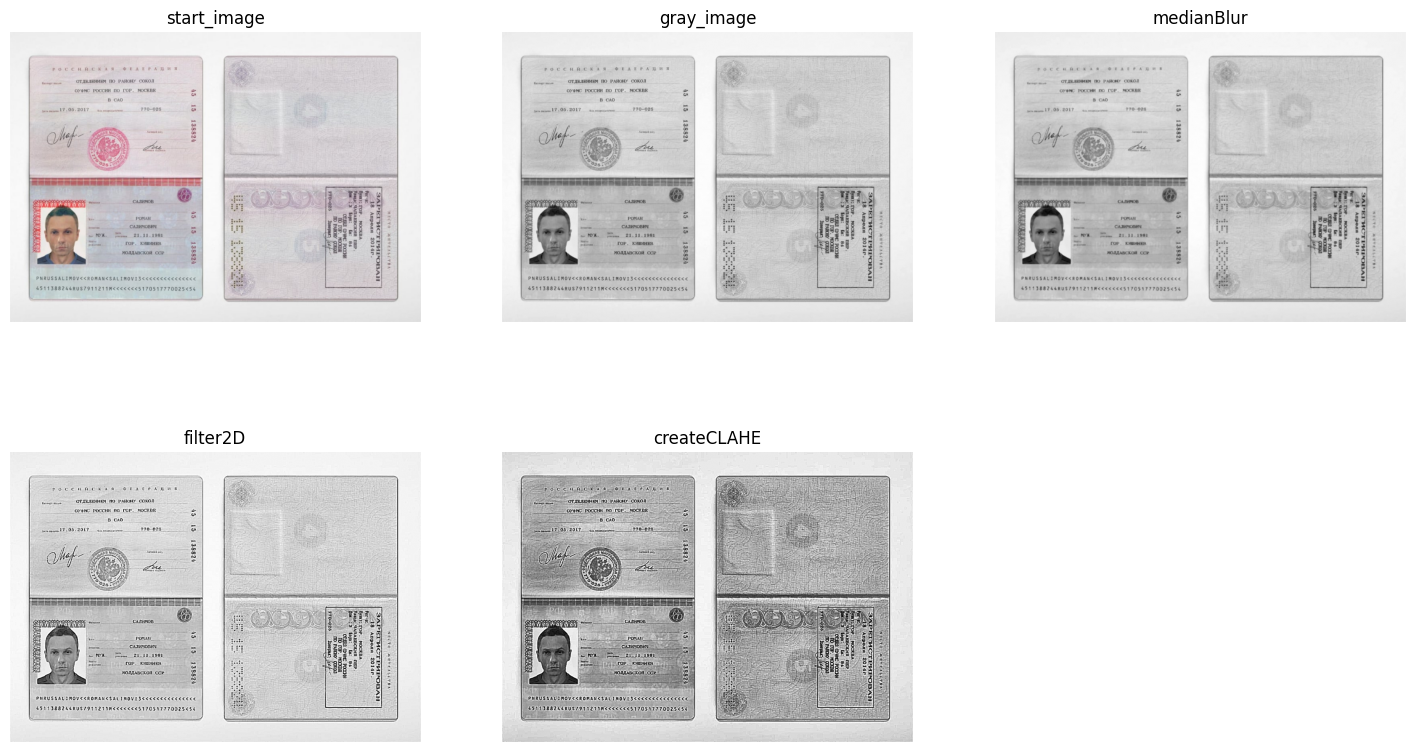

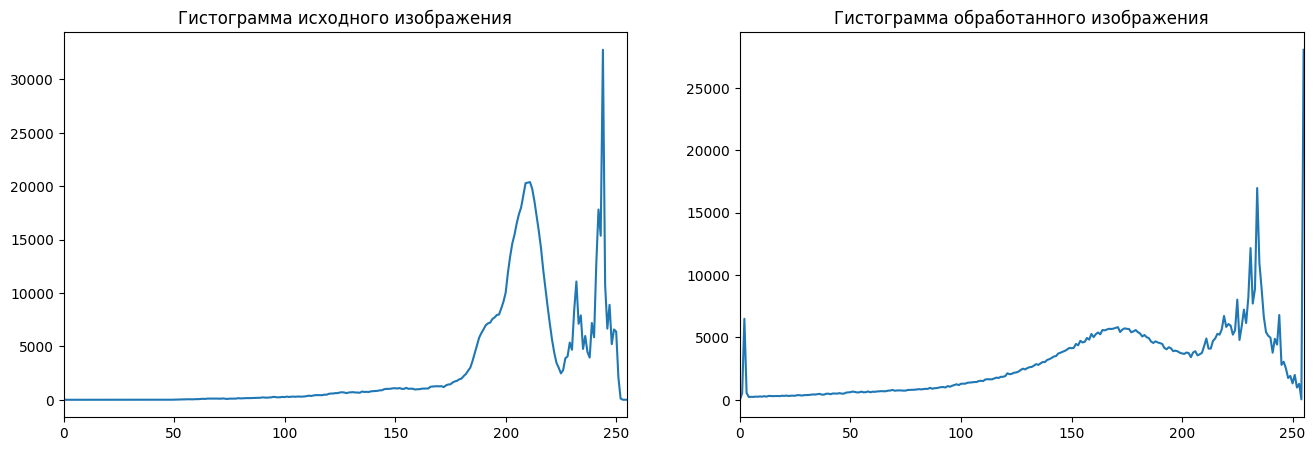

In [40]:
def improve_image(image):
  # Выполняем проверку рустой ли массив, пустая ли картинка, сколько каналов
  if image is None or not isinstance(image, np.ndarray):
    print('Массив пустой')
  if image.size == 0 or image.ndim not in (3, 2):
    print('Пустая картинка')
  if image.ndim == 3 and image.shape[2] not in (3, 4):
    print('1, 3 или 4 канала')

  # Если изображение имеет альфа-канал, то преобразуем в BGRA, если изображение черно-белое, то преобразуем в BGR
  if image.ndim == 3 and image.shape[2] == 4:
    image = cv2.cvtColor(image, cv2.COLOR_BGRA2BGR)
  elif image.ndim == 2:
    image = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)

  # Преобразуем в серый
  gray_img = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

  # Применяем медианный фильтр
  blur_img = cv2.medianBlur(gray_img, 3)

  # Создаём ядро для повышения резкости
  kernel = np.array([[-1, -1, -1],
                   [-1,  9, -1],
                   [-1, -1, -1]])

  # Применяем прямую свёртку
  filtered_img = cv2.filter2D(blur_img, -1, kernel)

  # Применяем метод CLAHE для улучшения контрасности изображения
  clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
  clahe_img = clahe.apply(filtered_img)

  # Визуализируем результаты преобразований
  # Создаём список с изображениями и подписями к ним
  images = [
      (cv2.cvtColor(image, cv2.COLOR_BGR2RGB), 'start_image', None),
      (gray_img, 'gray_image', 'gray'),
      (blur_img, 'medianBlur', 'gray'),
      (filtered_img, 'filter2D', 'gray'),
      (clahe_img, 'createCLAHE', 'gray')
  ]
  plt.figure(figsize=(18, 10))
  for i, (img, title, cmap) in enumerate(images, start=1):
    plt.subplot(2, 3, i)
    if cmap:
      plt.imshow(img, cmap=cmap)
    else:
      plt.imshow(img)
    plt.title(title)
    plt.axis('off')

  # Гистограммы до/после
  hist1 = cv2.calcHist([gray_img], [0], None, [256], [0, 256])
  hist2 = cv2.calcHist([clahe_img], [0], None, [256], [0, 256])

  plt.figure(figsize=(16, 5))
  plt.subplot(1, 2, 1)
  plt.plot(hist1)
  plt.xlim([0, 255])
  plt.title('Гистограмма исходного изображения')

  plt.subplot(1, 2, 2)
  plt.plot(hist2)
  plt.xlim([0, 255])
  plt.title('Гистограмма обработанного изображения')

  #plt.tight_layout()
  plt.show()

URL = 'https://i.otzyvru.com/2022/04/23/moshennik_62641dadb18cd.jpg'
resp = requests.get(URL, stream=True).raw
bgr_img = np.asarray(bytearray(resp.read()), dtype='uint8')
bgr_img = cv2.imdecode(bgr_img, cv2.IMREAD_UNCHANGED)

improve_image(bgr_img)

## **Дополнительное задание:**

- Поэкспериментируйте с параметрами медианного фильтра, ядром для фильтра повышения резкости и параметрами CLAHE для достижения наилучшего результата.
- Добавьте возможность передачи этих параметров в функцию `improve_scan` для более гибкой настройки обработки. **В качестве параметров по умолчанию установите те, которые показали себя лучше всего по результатам экспериментов**

**Пример с параметрами:**

```python
def improve_scan(image,
                 median_kernel_size=3,
                 sharp_kernel= np.array([[-1, -1, -1],
                                         [-1,  9, -1],
                                         [-1, -1, -1]]),
                 clahe_clip=2.0,
                 clahe_grid=(8,8),
                 visible=True):
    # Реализация с учетом переданных параметров
    ...
```


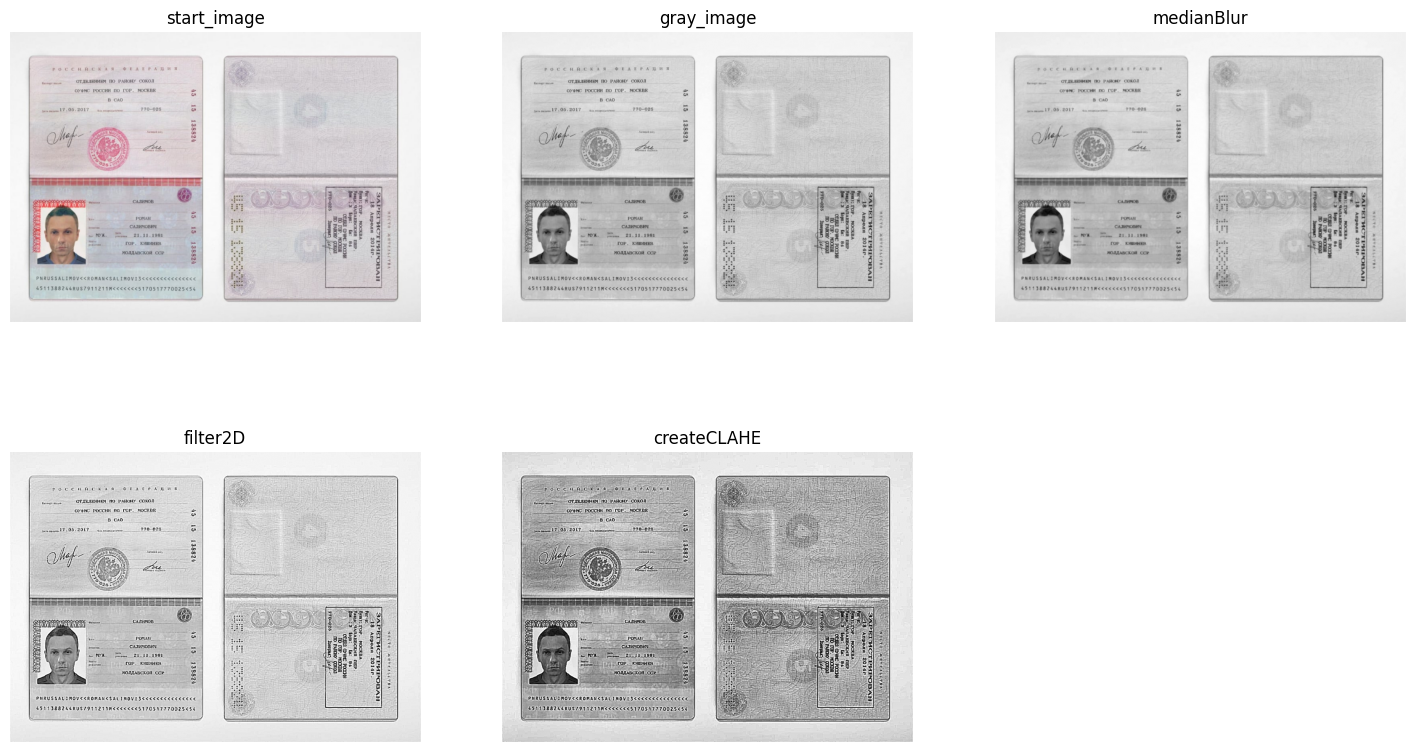

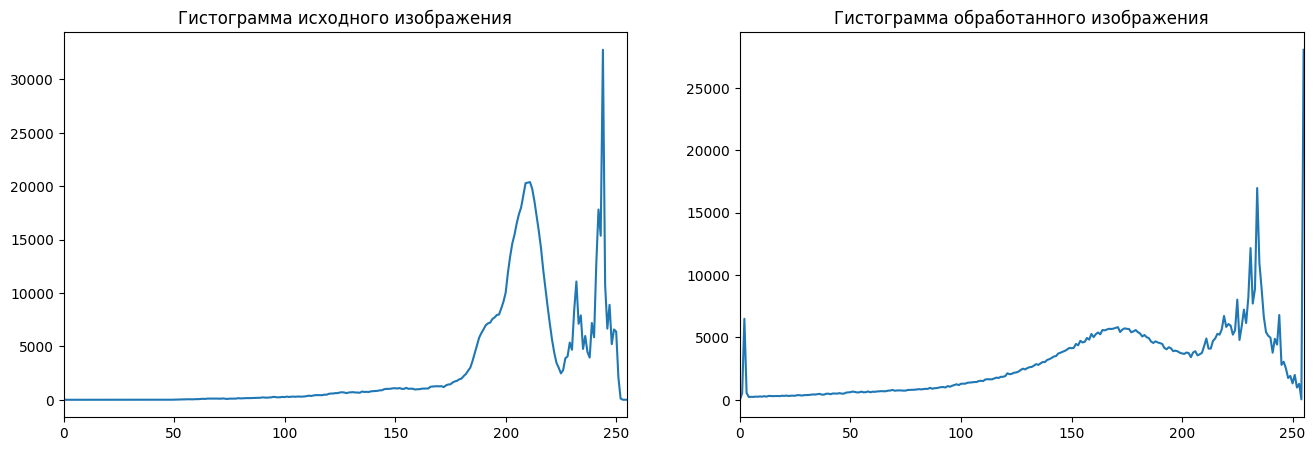

In [41]:
def improve_image(image,
                  median_kernel_size=3,
                  sharp_kernel=np.array([[-1, -1, -1],
                                         [-1, 9, -1],
                                         [-1, -1, -1]]),
                  clahe_clip=2.0,
                  clahe_grid=(8, 8),
                  visible=True):
  # Выполняем проверку рустой ли массив, пустая ли картинка, сколько каналов
  if image is None or not isinstance(image, np.ndarray):
    print('Массив пустой')
  if image.size == 0 or image.ndim not in (3, 2):
    print('Пустая картинка')
  if image.ndim == 3 and image.shape[2] not in (3, 4):
    print('1, 3 или 4 канала')

  # Если изображение имеет альфа-канал, то преобразуем в BGRA, если изображение черно-белое, то преобразуем в BGR
  if image.ndim == 3 and image.shape[2] == 4:
    image = cv2.cvtColor(image, cv2.COLOR_BGRA2BGR)
  elif image.ndim == 2:
    image = cv2.cvtColor(image, cv2.COLOR_GRAY2BGR)

  # Преобразуем в серый
  gray_img = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

  # Применяем медианный фильтр
  blur_img = cv2.medianBlur(gray_img, median_kernel_size)

  # Применяем прямую свёртку
  filtered_img = cv2.filter2D(blur_img, -1, sharp_kernel)

  # Применяем метод CLAHE для улучшения контрасности изображения
  clahe = cv2.createCLAHE(clipLimit=clahe_clip, tileGridSize=clahe_grid)
  clahe_img = clahe.apply(filtered_img)

  # Визуализируем результаты преобразований
  if visible:
  # Создаём список с изображениями и подписями к ним
    images = [
        (cv2.cvtColor(image, cv2.COLOR_BGR2RGB), 'start_image', None),
        (gray_img, 'gray_image', 'gray'),
        (blur_img, 'medianBlur', 'gray'),
        (filtered_img, 'filter2D', 'gray'),
        (clahe_img, 'createCLAHE', 'gray')
    ]
    plt.figure(figsize=(18, 10))
    for i, (img, title, cmap) in enumerate(images, start=1):
      plt.subplot(2, 3, i)
      if cmap:
        plt.imshow(img, cmap=cmap)
      else:
        plt.imshow(img)
      plt.title(title)
      plt.axis('off')

    # Гистограммы до/после
    hist1 = cv2.calcHist([gray_img], [0], None, [256], [0, 256])
    hist2 = cv2.calcHist([clahe_img], [0], None, [256], [0, 256])

    plt.figure(figsize=(16, 5))
    plt.subplot(1, 2, 1)
    plt.plot(hist1)
    plt.xlim([0, 255])
    plt.title('Гистограмма исходного изображения')

    plt.subplot(1, 2, 2)
    plt.plot(hist2)
    plt.xlim([0, 255])
    plt.title('Гистограмма обработанного изображения')

    plt.show()

URL = 'https://i.otzyvru.com/2022/04/23/moshennik_62641dadb18cd.jpg'
resp = requests.get(URL, stream=True).raw
bgr_img = np.asarray(bytearray(resp.read()), dtype='uint8')
bgr_img = cv2.imdecode(bgr_img, cv2.IMREAD_UNCHANGED)

improve_image(bgr_img)